# ADS-509 Assignment 1.1
## Collecting Text Data via API and Web Scraping

**Student Version**  

In this assignment you will:
- Collect story metadata via an API (Hacker News).
- Scrape discussion comments from HTML using BeautifulSoup.
- Merge into one tidy dataset (one row per comment with story metadata).
- Save results and run some quick checks/EDA.

Although the discussion posts are available via the HackerNews API, this mirrors real-world pipelines where structured APIs don’t expose the exact text you need, so you complement them with carefully designed scrapers.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

Work through this notebook as if it were a worksheet, completing the code sections marked with **TODO** in the cells provided. Similarly, written questions will be marked by a "Q:" and will have a corresponding "A:" spot for you to fill in with your answers. **Make sure to answer every question marked with a Q: for full credit**.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential import statements and make sure that all such statements are moved into the designated cell.

A .pdf of this notebook, with your completed code and written answers, is what you should submit in Canvas for full credit. **DO NOT SUBMIT A NEW NOTEBOOK FILE OR A RAW .PY FILE**. Submitting in a different format makes it difficult to grade your work, and students who have done this in the past inevitably miss some of the required work or written questions.

## Imports and Definitions

First we import our libraries, set up our folder structure, and define some useful functions and variables.

**TODO**
- update the directory names with whatever path you would like to use to store your data
- define a function that will cause your code to "sleep" for a random interval between 1 and 2 seconds

In [1]:
import os, json, time, random
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Polite scraping: set a clear user agent and throttle requests a bit
HEADERS = {"User-Agent": "MADS-LLM-2025-Student/1.0 (+https://example.edu)"}
BASE = "https://hacker-news.firebaseio.com/v0"

def sleep_politely(sleep_range=(1.0, 2.0)):
    """Sleep for a random interval (seconds) within sleep_range."""
    time.sleep(random.uniform(*sleep_range))


In [3]:
# All paths are relative to the notebook's directory
DATA_DIR = 'data/module1'
RAW_API_DIR = os.path.join(DATA_DIR, 'raw_api')
RAW_HTML_DIR = os.path.join(DATA_DIR, 'raw_html')
for d in [DATA_DIR, RAW_API_DIR, RAW_HTML_DIR]:
    os.makedirs(d, exist_ok=True)


## API Data Collection

Here we will use the **requests** library to interact with the HackerNews API. Our ultimate goal is to create a dataset with metadata and discussion posts for 50 of the top stories on this website, so first we will use the API to get the top story IDs.

**TODO**:
- Read through the HackerNews API documentation (https://github.com/HackerNews/API) and use the requests library to pull the IDs for all top news stories. *Be sure to use the headers and timeout arguments*.

**Q:** What do the headers and timeout arguments in the requests library do?

**A:** The `headers` argument attaches HTTP request headers to each call. The most important header here is `User-Agent`, which identifies our scraper to the server. Many sites inspect the User-Agent to distinguish automated bots from real browsers, and a descriptive User-Agent is good practice — it lets a site owner contact you if there is an issue, and it avoids being silently blocked or served different content. Without it, `requests` sends a generic `python-requests/x.x.x` string that many servers flag or block.

The `timeout` argument sets the maximum number of seconds to wait for the server to respond before raising a `requests.exceptions.Timeout` error. Without a timeout, a slow or unresponsive server could cause our script to hang indefinitely. Setting it to a reasonable value (e.g., 10 seconds) ensures our program fails fast and predictably rather than stalling silently.

In [5]:
# Get a big list of top story IDs
r = requests.get(f"{BASE}/topstories.json", headers=HEADERS, timeout=10)
r.raise_for_status()
top_ids = r.json()
print('Total top story ids returned:', len(top_ids))

# Cache candidate IDs to disk so re-runs always use the same 50 stories
CANDIDATE_N = 50
_ids_cache = os.path.join(RAW_API_DIR, 'candidate_ids.json')
if os.path.exists(_ids_cache):
    with open(_ids_cache) as f:
        candidate_ids = json.load(f)
    print('Loaded candidate IDs from cache')
else:
    candidate_ids = top_ids[:CANDIDATE_N]
    with open(_ids_cache, 'w') as f:
        json.dump(candidate_ids, f)

len(candidate_ids), candidate_ids[:5]  # Print 5 of the IDs as a self-check


Total top story ids returned: 500


(50, [48586631, 48583928, 48585746, 48552767, 48586299])

Next we need to use our list of article IDs to pull and organize the metadata that we want to include in our final dataset.

**TODO**:
- Use the HackerNews API documentation to pull the metadata for each of the stories in your candidate_ids list.
- Filter your stories for those with discussion threads. Hint: look for the "descendants" column.
- Format your stories with their associated metadata into a pandas dataframe. Hint: check out the Pandas `json_normalize()` function

In [6]:
def fetch_item(item_id):
    """Fetch a single HN item from the API; return cached copy if available."""
    fp = os.path.join(RAW_API_DIR, f"item_{item_id}.json")
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return json.load(f)
    r = requests.get(f"{BASE}/item/{item_id}.json", headers=HEADERS, timeout=10)
    r.raise_for_status()
    data = r.json()
    with open(fp, 'w', encoding='utf-8') as f:
        json.dump(data, f)
    sleep_politely()  # avoid hammering the API
    return data

items = []
for idx, i in enumerate(candidate_ids):
    if idx % 5 == 0:
        print(f"{idx}/{len(candidate_ids)}")
    items.append(fetch_item(i))

# Exclude stories with no comments (descendants == 0 or missing)
stories = [item for item in items if item and item.get('descendants', 0) > 0]

# Ask HN / Show HN posts have no external url — substitute the HN thread url
keep_cols = ["id", "title", "by", "time", "url", "score", "descendants"]
stories_df = pd.json_normalize(stories)
if 'url' not in stories_df.columns:
    stories_df['url'] = None
stories_df = stories_df.reindex(columns=keep_cols)
stories_df['url'] = stories_df['url'].fillna(
    'https://news.ycombinator.com/item?id=' + stories_df['id'].astype(str)
)

print('Stories w/ discussion:', len(stories_df))
stories_df.head()


0/50
5/50
10/50
15/50
20/50
25/50
30/50
35/50
40/50
45/50
Stories w/ discussion: 48


,id,title,by,time,url,score,descendants
0,48586631,A website that lists websites to submit your w...,azeemkafridi,1781795563,https://www.submission.directory/,180,54
1,48583928,I found 10k GitHub repositories distributing T...,theorchid,1781783143,https://orchidfiles.com/github-repositories-di...,332,95
2,48585746,Swiss parliament lifts ban on new nuclear powe...,leonidasrup,1781792227,https://www.bluewin.ch/en/news/switzerland/par...,339,195
3,48552767,Notes from Tired Egyptian Whose Job Is Explain...,Geekette,1781602590,https://www.mcsweeneys.net/articles/notes-from...,13,11
4,48586299,Launch HN: TesterArmy (YC P26) – Agents that t...,okwasniewski,1781794184,https://tester.army,48,26


## Webscraping

Next, we will use our list of story IDs to scrape the discussion threads from HackerNews using the BeautifulSoup library.

**TODO**:
- Use the requests library to pull the html for each story's comment page on Hacker News (https://news.ycombinator.com/). Hint: you'll need to go to the website to see how to format your url properly.
- Use the BeautifulSoup library to extract the user, comment id, time span, and comment text from each story's HTML. Hint: use the html inspector (ctrl+shift+i) to identify relevant html tags in your browser.
- Format the comment threads into a pandas dataframe with the story id and one row per comment.

**Q**: Find the HackerNews robots.txt. What does it say about scraping, and are we acting within its stated policy?

**A**: The HackerNews `robots.txt` (https://news.ycombinator.com/robots.txt) disallows automated access to several paths including `/x`, `/r`, `/vote`, `/reply`, `/submitted`, `/threads`, `/leaders`, `/item?id=*&goto=*` (redirect targets), and a few others. However, it does **not** disallow the `/item?id=<id>` path we are using to access comment pages. It also specifies `Crawl-delay: 30`, instructing automated clients to wait at least 30 seconds between requests to avoid overloading the server.

We are acting within its stated policy on both counts: we only access `/item?id=...` pages (which are explicitly allowed), and we sleep 30–31 seconds between each HTML request via `sleep_politely(sleep_range=(30.0, 31.0))`. We also identify ourselves with a descriptive `User-Agent` header rather than disguising our scraper as a browser.

In [16]:
def get_discussion_html(story_id):
    """Fetch and cache the HN comment page HTML for a given story ID."""
    fp = os.path.join(RAW_HTML_DIR, f"hn_{story_id}.html")
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return f.read()
    url = f"https://news.ycombinator.com/item?id={story_id}"
    # Retry up to 3 times on 429 with linear backoff (60s, 120s, 180s)
    for attempt in range(3):
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code == 429:
            wait = 60 * (attempt + 1)
            print(f"  429 rate-limited on {story_id}, waiting {wait}s...")
            time.sleep(wait)
            continue
        r.raise_for_status()
        html = r.text
        with open(fp, 'w', encoding='utf-8') as f:
            f.write(html)
        sleep_politely(sleep_range=(30.0, 31.0))  # robots.txt requires Crawl-delay: 30
        return html
    raise Exception(f"Failed to fetch story {story_id} after 3 attempts")


def parse_comments_from_html(html, story_id):
    """Extract comment metadata and text from a HN discussion page."""
    soup = BeautifulSoup(html, 'html.parser')
    rows = []
    # Each top-level and nested comment occupies a <tr class="athing comtr"> row
    for tr in soup.find_all('tr', class_='athing comtr'):
        comment_id = tr.get('id')
        user_tag = tr.find('a', class_='hnuser')
        user = user_tag.text.strip() if user_tag else None
        age_tag = tr.find('span', class_='age')
        # The 'title' attribute contains the ISO timestamp; inner text is relative ("3 hours ago")
        time_text = age_tag.get('title') if age_tag else None
        commtext_tag = tr.find('div', class_='commtext')
        # get_text strips HTML tags (links, code blocks) from the comment body
        comment_text = commtext_tag.get_text(separator=' ', strip=True) if commtext_tag else None
        # Skip deleted/dead comments which have no text
        if comment_text:
            rows.append({
                'story_id': story_id,
                'comment_id': comment_id,
                'user': user,
                'time_text': time_text,
                'comment_text': comment_text,
            })
    return rows


all_comments = []
for idx, sid in enumerate(stories_df['id'].tolist()):
    if idx % 5 == 0:
        print(f"{idx}/{len(stories_df['id'])}")
    html = get_discussion_html(sid)
    all_comments.extend(parse_comments_from_html(html, sid))

comments_df = pd.DataFrame(all_comments)
print('Total comments scraped:', len(comments_df))
comments_df.head()


0/48
5/48
10/48
15/48
20/48
25/48
30/48
35/48
40/48
45/48
Total comments scraped: 4811


,story_id,comment_id,user,time_text,comment_text
0,48586631,48588908,marc,2026-06-18T17:49:33 1781804973,Fun story: I built BetaList 16 years ago which...
1,48586631,48589030,kilobaud,2026-06-18T17:58:03 1781805483,Thanks for helping us launch LocalXpose howeve...
2,48586631,48587201,transitorykris,2026-06-18T15:47:47 1781797667,What’s old is new again. In the 90s we used se...
3,48586631,48587322,dofm,2026-06-18T15:54:07 1781798047,Was that creaking sound your knee or mine?
4,48586631,48587392,transitorykris,2026-06-18T15:58:30 1781798310,"Hard to say, drkoop.com is a landing page now"


## Combine Datasets

Now we have two dataframes that need to be combined into a single dataset. Luckily, these dataframes have a shared key which will make it relatively simple to combine them, but that is often not the case, so you need to be creative about which pieces of data you could use to merge data from multiple sources.

**TODO**
- Combine your `stories_df` and `comments_df` dataframes using the shared key so that the resulting dataset has one line per comment.
- As a final cleaning step, convert the timestamp column from Unix epoch format to a pandas datetime format

**Q**: If we didn't have a shared key for the two dataframes in this scenario, what could you use instead to join them?

**A**: Several alternatives exist depending on what information is available in both sources:

1. **Story URL** — the HN discussion page URL is structured as `https://news.ycombinator.com/item?id=<story_id>`, so we could reconstruct it from `stories_df['id']` and match it against a URL captured during scraping. This would be an exact match.

2. **Story title** — the `<title>` tag of each scraped HTML page contains the article title, which also appears in the API metadata. This would require fuzzy string matching (e.g., with `difflib` or the `fuzzywuzzy` library) to handle minor formatting differences, but would work reliably here since titles are unique within the dataset.

3. **Timestamp + author** — combining the story's Unix timestamp (from the API) with the author's username (also in the API and visible in the HTML page header) would form a composite key unique enough to join on in most cases.

In general, when no single shared key exists, the best strategy is to identify a combination of attributes that is jointly unique across both sources and use a composite key or fuzzy join.

In [17]:
# Left join keeps all comments; story metadata columns are added to each row
merged_df = comments_df.merge(stories_df, left_on='story_id', right_on='id', how='left')

# HN API returns Unix epoch seconds; convert for readability in future analyses
merged_df['story_time'] = pd.to_datetime(merged_df['time'], unit='s')

assert merged_df['comment_text'].notna().all()
print('Rows in merged dataset:', len(merged_df))
merged_df.sample(3)


Rows in merged dataset: 4811


,story_id,comment_id,user,time_text,comment_text,id,title,by,time,url,score,descendants,story_time
4197,48582464,48587680,embedding-shape,2026-06-18T16:16:29 1781799389,"Not even on Cloudflare it seems, so the joke d...",48582464,"I need your clothes, your boots, and your moto...",ingve,1781771284,https://rbelmont.mameworld.info/?p=1725,106,101,2026-06-18 08:28:04
403,48583386,48588502,tyre,2026-06-18T17:17:24 1781803044,> It would be in the insurance companies’ inte...,48583386,Hospitals and universities repurposing drugs a...,giuliomagnifico,1781778802,https://www.kcl.ac.uk/news/hospitals-and-unive...,204,84,2026-06-18 10:33:22
2363,48579650,48580829,davidivadavid,2026-06-18T04:29:27 1781756967,That's definitely an important point to consid...,48579650,Midjourney Medical,ricochet11,1781747991,https://www.midjourney.com/medical/blogpost,1196,810,2026-06-18 01:59:51


## Save your dataset for future use

We will be using this dataset in future assignments, so use this code to save it to file.

In [11]:
# Persist the merged dataset for use in future module assignments
out_csv = os.path.join(DATA_DIR, 'hn_comments_with_storymeta.csv')
merged_df.to_csv(out_csv, index=False)
out_csv


'data/module1/hn_comments_with_storymeta.csv'

## Validation

This section is used for grading. Please run these cells before submission, but do not change any of the code.

In [18]:
comments_per_story = (
    merged_df.groupby(['story_id','title']).size()
    .rename('n_comments').reset_index()
)
comments_per_story.sort_values('n_comments', ascending=False).head(10)

,story_id,title,n_comments
15,48579650,Midjourney Medical,805
9,48571081,Lore – Open source version control system desi...,643
8,48565498,"US holds off blacklisting DeepSeek, more than ...",553
29,48584207,Microsoft new Outlook takes 10 seconds to do w...,274
16,48580209,"Local Qwen isn't a worse Opus, it's a differen...",221
33,48585746,Swiss parliament lifts ban on new nuclear powe...,199
19,48582320,AMD silently removes memory encryption from co...,181
18,48581458,DeepSeek Introduces Vision,158
28,48584135,Emacs 31 is around the corner: The changes I'm...,158
17,48581070,I hate compilers,127


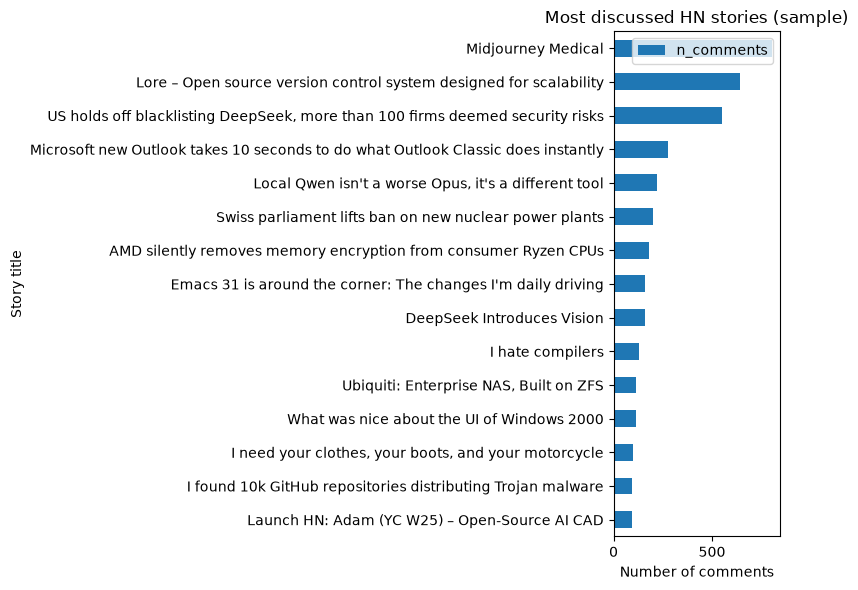

In [19]:
ax = (
    comments_per_story.sort_values('n_comments')
    .tail(15)
    .plot(kind='barh', x='title', y='n_comments', figsize=(8,6))
)
ax.set_xlabel('Number of comments')
ax.set_ylabel('Story title')
ax.set_title('Most discussed HN stories (sample)')
plt.tight_layout()
plt.show()

In [20]:
merged_df['user'].fillna('unknown').value_counts().head(10)

user
zachdive           34
inigyou            27
Arodex             22
embedding-shape    21
bryanlarsen        19
CPLX               17
maccard            16
fc417fc802         15
ibejoeb            13
1718627440         13
Name: count, dtype: int64

<small>This assignment was designed with the assistance of ChatGPT.</small>